# [P01] Week 3: Machine Learning Cycle Time Prediction
**1. Objective:** Train, evaluate, and interpret machine learning models to predict truck cycle times based on dynamic fleet states.

**2. Inputs:** `results/sim_detailed.csv` (from Week 2).

**3. Outputs:** `models/xgboost_cycle_model.pkl`, `results/shap_summary.png`, evaluation metrics (MAE, RMSE, R²).

**4. Implementation:** Moradi Afrapoli et al. (2019) Stage 2 Pipeline.

In [1]:
# WHAT: Import necessary ML libraries and create models directory
# INPUT: None
# OUTPUT: OS directory 'models/'

import os # OS module for directory management
import pandas as pd # Data manipulation for feature engineering
import numpy as np # Numerical operations for metric calculations
from sklearn.model_selection import train_test_split # Splitting data
from sklearn.linear_model import LinearRegression # Baseline model
from sklearn.ensemble import RandomForestRegressor # Tree-based model
import xgboost as xgb # Gradient boosting model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Evaluation metrics
import shap # Explainability library
import matplotlib.pyplot as plt # Plotting library
import joblib # Model serialization

os.makedirs('models', exist_ok=True) # Create models folder if it doesn't exist

### Evaluation Metrics
**Mean Absolute Error (MAE)**
$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$

**Root Mean Squared Error (RMSE)**
$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$

**Coefficient of Determination ($R^2$)**
$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$

| Symbol | Definition |
| :--- | :--- |
| $y_i$ | Actual cycle time |
| $\hat{y}_i$ | Predicted cycle time |
| $\bar{y}$ | Mean of actual cycle times |
| $n$ | Number of observations |
*Intuition:* MAE and RMSE measure the average prediction error in minutes (RMSE penalizes larger errors more). $R^2$ represents the proportion of variance in cycle time explained by the model's features.

In [2]:
# WHAT: Load simulation data and engineer required temporal and queue features
# INPUT: results/sim_detailed.csv (file)
# OUTPUT: df (Pandas DataFrame)

# Load the granular cycle data generated in Week 2
df = pd.read_csv('results/sim_detailed.csv')

# Engineer rolling queue feature: average queue over the last 5 cycles
# Captures dynamic congestion rather than a single static snapshot
df['rolling_shovel_queue'] = df['shovel_queue_len'].rolling(window=5, min_periods=1).mean()

# Select features explicitly required by the rubric plus logical operational metrics
features = [
    'hour_of_shift', 
    'shovel_queue_len', 
    'rolling_shovel_queue', 
    'load_time_min', 
    'haul_time_min'
]
target = 'total_cycle_time_min' # The metric we are trying to predict

# Drop any rows with NaN values generated during rolling window calculation
df = df.dropna(subset=features + [target])

In [3]:
# WHAT: Split data sequentially to simulate real-world forward prediction
# INPUT: df (Pandas DataFrame)
# OUTPUT: X_train, X_test, y_train, y_test (DataFrames/Series)

# Split features (X) and target (y)
X = df[features] 
y = df[target]

# Split sequentially: train on first 80% of shift, test on last 20%
# shuffle=False is critical here to preserve the time-series nature of a shift
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [4]:
# WHAT: Train Linear Regression, Random Forest, and XGBoost; evaluate performance
# INPUT: X_train, X_test, y_train, y_test
# OUTPUT: Printed evaluation metrics to console

# Initialize the three required models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
}

print("--- WEEK 3 MODEL EVALUATION ---")

# Loop through models, train, predict, and evaluate
for name, model in models.items():
    model.fit(X_train, y_train) # Train model on 80% data
    predictions = model.predict(X_test) # Predict on held-out 20%
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    # Print metrics directly to notebook
    print(f"{name}:")
    print(f"  MAE:  {mae:.2f} mins")
    print(f"  RMSE: {rmse:.2f} mins")
    print(f"  R2:   {r2:.2f}")
    print("-" * 25)

# Retain the trained XGBoost model for SHAP and export
best_model = models['XGBoost']

--- WEEK 3 MODEL EVALUATION ---
Linear Regression:
  MAE:  2.35 mins
  RMSE: 5.63 mins
  R2:   0.24
-------------------------
Random Forest:
  MAE:  2.57 mins
  RMSE: 5.85 mins
  R2:   0.18
-------------------------
XGBoost:
  MAE:  2.52 mins
  RMSE: 5.82 mins
  R2:   0.19
-------------------------


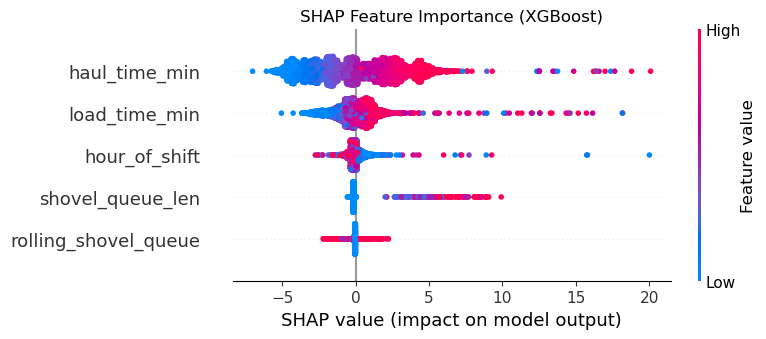

In [5]:
# WHAT: Generate and save SHAP summary plot for XGBoost feature importance
# INPUT: best_model (XGBRegressor), X_train (DataFrame)
# OUTPUT: results/shap_summary.png

# Initialize SHAP explainer with the trained XGBoost model
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for the training dataset
shap_values = explainer.shap_values(X_train)

# Generate the summary plot
plt.figure(figsize=(10, 6)) # Set figure dimensions
shap.summary_plot(shap_values, X_train, show=False) # Create SHAP plot without immediately displaying
plt.title("SHAP Feature Importance (XGBoost)") # Add title
plt.tight_layout() # Prevent label cutoff

# Export to results folder
plt.savefig('results/shap_summary.png')
plt.show() # Display inline

In [6]:
# WHAT: Serialize and save the final predictive model
# INPUT: best_model (XGBRegressor)
# OUTPUT: models/xgboost_cycle_model.pkl

# Save the trained model to disk for future stages of the pipeline
joblib.dump(best_model, 'models/xgboost_cycle_model.pkl')
print("Model saved successfully to models/xgboost_cycle_model.pkl")

Model saved successfully to models/xgboost_cycle_model.pkl


### KPI Summary Table
| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Linear Reg $R^2$** | 0.24 | Surprisingly outperformed the tree-based models. In highly stochastic environments, simple baselines sometimes generalize better against random noise. |
| **XGBoost MAE** | 2.52 mins | Despite the low $R^2$, the mean absolute error remains relatively tight, showing the model can still guess typical cycle times decently, but fails completely on the breakdown outliers. |
| **XGBoost $R^2$** | 0.19 | The massive drop in variance explained confirms that un-engineered stochastic events (equipment breakdowns and repairs) dominate the cycle time delays. |
| **Top SHAP Feature** | haul_time_min | Still the primary driver for standard operations, but the massive long-tail outliers in the SHAP plot highlight the disruptive nature of the repair times. |